In [22]:
import requests, bs4, pandas, matplotlib
print("Todo OK")

Todo OK


In [23]:
import requests
from bs4 import BeautifulSoup

url = "https://books.toscrape.com/"
response = requests.get(url)

print(response.status_code)  # debe imprimir 200
print(response.text[:500])    # primeros 500 chars del HTML

200
<!DOCTYPE html>
<!--[if lt IE 7]>      <html lang="en-us" class="no-js lt-ie9 lt-ie8 lt-ie7"> <![endif]-->
<!--[if IE 7]>         <html lang="en-us" class="no-js lt-ie9 lt-ie8"> <![endif]-->
<!--[if IE 8]>         <html lang="en-us" class="no-js lt-ie9"> <![endif]-->
<!--[if gt IE 8]><!--> <html lang="en-us" class="no-js"> <!--<![endif]-->
    <head>
        <title>
    All products | Books to Scrape - Sandbox
</title>

        <meta http-equiv="content-type" content="text/html; charset=UTF-8" /


In [24]:
soup = BeautifulSoup(response.text, "html.parser")
print(soup.title.text)  # imprime el título de la página


    All products | Books to Scrape - Sandbox



Seleccionar todos los libros

In [25]:
rating_map = {"One":1, "Two":2, "Three":3,
               "Four":4, "Five":5}
libros = []

for art in soup.select("article.product_pod"):
    titulo = art.select_one("h3 a")["title"]
    precio = art.select_one("p.price_color").text.strip()
    r_clase = art.select_one("p.star-rating")["class"][1]
    rating  = rating_map.get(r_clase, 0)
    stock   = art.select_one("p.availability").text.strip()

    libros.append({
        "titulo": titulo,
        "precio": precio,
        "rating": rating,
        "stock": stock
    })

print(f"Extraídos {len(libros)} libros")
print(libros[0])

Extraídos 20 libros
{'titulo': 'A Light in the Attic', 'precio': 'Â£51.77', 'rating': 3, 'stock': 'In stock'}


Scrapping de todas las paginas

In [26]:
import time

BASE = "https://books.toscrape.com/catalogue/"
url  = "https://books.toscrape.com/catalogue/page-1.html"
todos = []

while url:
    r = requests.get(url)
    soup = BeautifulSoup(r.text, "html.parser")

    for art in soup.select("article.product_pod"):
        titulo = art.select_one("h3 a")["title"]
        precio = art.select_one("p.price_color").text.strip()
        r_clase = art.select_one("p.star-rating")["class"][1]
        rating  = rating_map.get(r_clase, 0)
        stock   = art.select_one("p.availability").text.strip()

        todos.append({
            "titulo": titulo,
            "precio": precio,
            "rating": rating,
            "stock": stock
    })

#busca el enlace "next
    sig = soup.select_one("li.next a")
    url = BASE + sig["href"] if sig else None
    time.sleep(0.5)  # pausa entre peticiones

print(f"Total: {len(todos)} libros")  # debe dar 1000



Total: 1000 libros


In [27]:
import pandas as pd

df = pd.DataFrame(todos)

# Limpia el precio: "Â£51.77" → 51.77,
df["precio_num"] = (df["precio"]
    .str.replace(r"[^\d.]", "", regex=True)
    .astype(float))

print(df.head())
print(df.describe())

# Guardar,
df.to_csv("libros.csv", index=False, encoding="utf-8-sig")
print(" Guardado en libros.csv")




                                  titulo   precio  rating     stock  \
0                   A Light in the Attic  Â£51.77       3  In stock   
1                     Tipping the Velvet  Â£53.74       1  In stock   
2                             Soumission  Â£50.10       1  In stock   
3                          Sharp Objects  Â£47.82       4  In stock   
4  Sapiens: A Brief History of Humankind  Â£54.23       5  In stock   

   precio_num  
0       51.77  
1       53.74  
2       50.10  
3       47.82  
4       54.23  
            rating  precio_num
count  1000.000000  1000.00000
mean      2.923000    35.07035
std       1.434967    14.44669
min       1.000000    10.00000
25%       2.000000    22.10750
50%       3.000000    35.98000
75%       4.000000    47.45750
max       5.000000    59.99000
 Guardado en libros.csv


Analiza y visualiza datos

Precio medio: £35.07
Más caro: The Perfect Play (Play by Play #1)
rating
1    34.56
2    34.81
3    34.69
4    36.09
5    35.37
Name: precio_num, dtype: float64


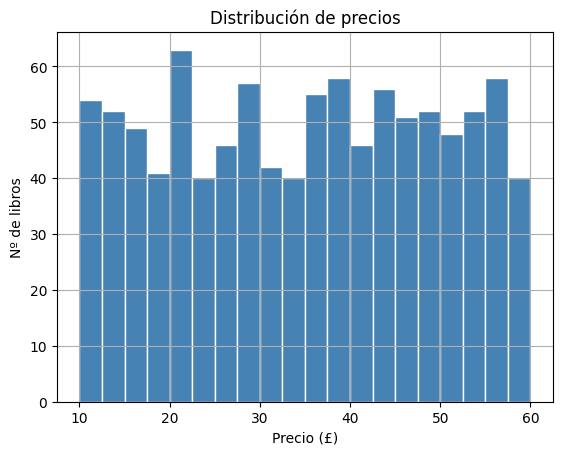

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("libros.csv")

#Estadísticas básicas,
print(f"Precio medio: £{df['precio_num'].mean():.2f}")
print(f"Más caro: {df.loc[df['precio_num'].idxmax(), 'titulo']}")
print(df.groupby("rating")["precio_num"].mean().round(2))

#Histograma de precios,
df["precio_num"].hist(bins=20, color="steelblue", edgecolor="white")
plt.title("Distribución de precios")
plt.xlabel("Precio (£)")
plt.ylabel("Nº de libros")
plt.savefig("precios.png")
plt.show()

Hacer 4 consultas libres sobre libros.csv sobre los libros + 2 graficos

In [29]:
# Cuantas filas y columnas tiene la tabla
df.shape

(1000, 5)

In [30]:
#busca todos los libros que tienen la palabra "Big" en titulo

import re

texto = "\n".join(df["titulo"])

patron = r"(\bBig\b.*)"
resultados =re.findall(patron, texto)

print(resultados)


['Big Things', 'Big Magic: Creative Living Beyond Fear', 'Big Ideas Simply Explained)', 'Big Difference', 'Big Little Lies']


In [31]:
#busca todos los libros que empiezan por letra "A"

texto = "\n".join(df["titulo"])

patron = r"^A.*"
resultados =re.findall(patron, texto, flags=re.MULTILINE)

print(resultados)


['A Light in the Attic', "America's Cradle of Quarterbacks: Western Pennsylvania's Football Factory from Johnny Unitas to Joe Montana", 'Aladdin and His Wonderful Lamp', 'Avatar: The Last Airbender: Smoke and Shadow, Part 3 (Smoke and Shadow #3)', 'Algorithms to Live By: The Computer Science of Human Decisions', 'A World of Flavor: Your Gluten Free Passport', 'A Piece of Sky, a Grain of Rice: A Memoir in Four Meditations', 'A Murder in Time', 'A Flight of Arrows (The Pathfinders #2)', 'A Fierce and Subtle Poison', 'A Court of Thorns and Roses (A Court of Thorns and Roses #1)', "Ayumi's Violin", 'Anonymous', 'Amy Meets the Saints and Sages', 'Amid the Chaos', 'Amatus', 'Agnostic: A Spirited Manifesto', 'Art Ops Vol. 1', 'Aristotle and Dante Discover the Secrets of the Universe (Aristotle and Dante Discover the Secrets of the Universe #1)', 'Angels Walking (Angels Walking #1)', 'Angels & Demons (Robert Langdon #1)', 'All the Light We Cannot See', 'Adulthood Is a Myth: A "Sarah\'s Scribbl

Libros por letra inicial

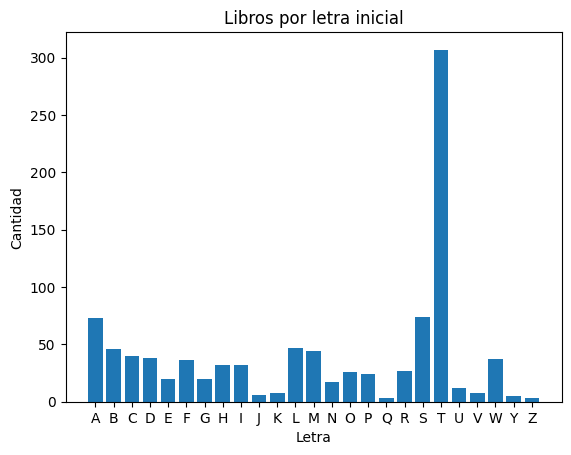

In [32]:
# busca primera letra del titulo y la guarda en nueva columna

df["primera_letra"] = df["titulo"].str.strip().str[0].str.upper()

#filtra letras A-Z porque hay simbolos raros que no queremos en la grafica

df_letras = df[df["primera_letra"].str.match(r"[A-Z]")]

# conteo de libros por la primera letra

conteo = df_letras["primera_letra"].value_counts().sort_index()

# Grafico barplot 

plt.bar(conteo.index, conteo.values)
plt.title("Libros por letra inicial")
plt.xlabel("Letra")
plt.ylabel("Cantidad")
plt.show()

Valoracion media: 2.92


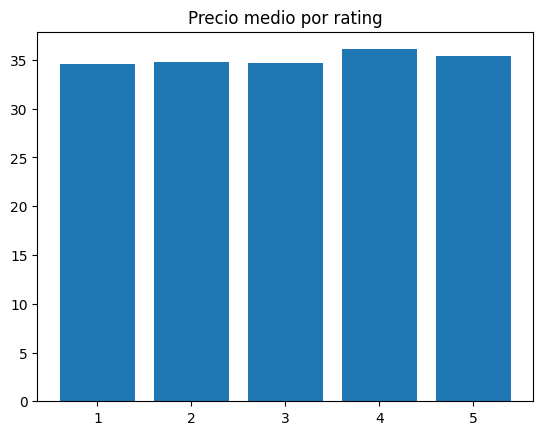

In [33]:
print(f"Valoracion media: {df['rating'].mean():.2f}")

media =df.groupby("rating")["precio_num"].mean()
plt.bar(media.index, media.values)
plt.title("Precio medio por rating")
plt.show()


El libro mas caro: The Perfect Play (Play by Play #1)
                                                titulo  precio_num
648                 The Perfect Play (Play by Play #1)       59.99
617                  Last One Home (New Beginnings #1)       59.98
860                   Civilization and Its Discontents       59.95
560                     The Barefoot Contessa Cookbook       59.92
366                          The Diary of a Young Girl       59.90
657  The Bone Hunters (Lexy Vaughan & Steven Macaul...       59.71
133  Thomas Jefferson and the Tripoli Pirates: The ...       59.64
387                      Boar Island (Anna Pigeon #19)       59.48
549  The Man Who Mistook His Wife for a Hat and Oth...       59.45
393                          The Improbability of Love       59.45


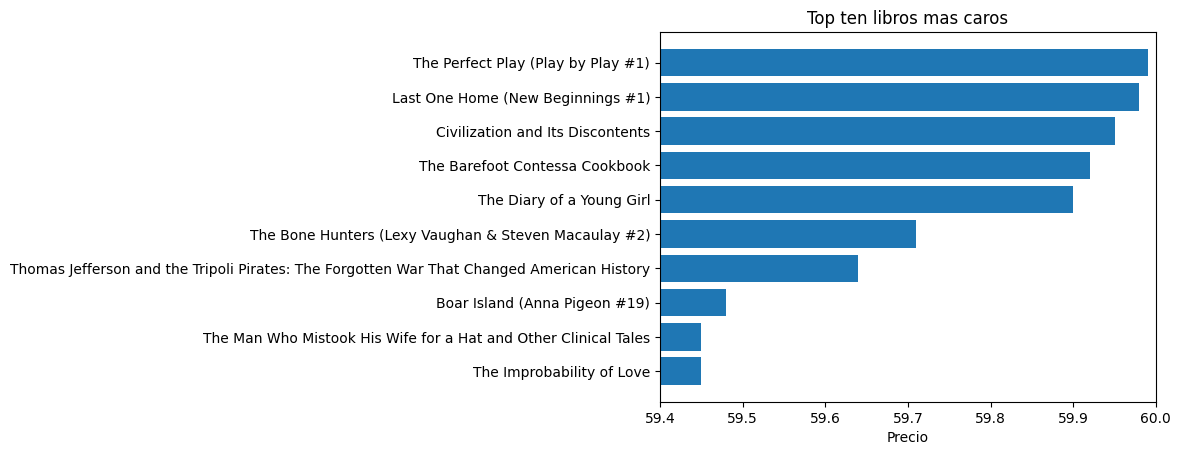

In [ ]:
#top 10 libros mas caros

print("El libro mas caro:", df.loc[df["precio_num"].idxmax(), "titulo"])

top10 = df.sort_values(by="precio_num", ascending=False).head(10)
print(top10[["titulo", "precio_num"]])

#grafico de barras horizontales

plt.barh(top10["titulo"], top10["precio_num"])
plt.gca().invert_yaxis() # Invierte el eje Y, esta mas ordenado y claro
plt.xlim(59.4, 60)  # limites - muy importante aqui, porque las diferencias de precios son muy pequeñas

plt.xlabel("Precio")
plt.title("Top ten libros mas caros")
plt.show()